In [12]:
import joblib
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('..')
from utils.extract_features import extract_features

In [13]:
df = pd.read_csv("../XSS_dataset.csv")
print(f"Загружено {len(df)} строк")

Загружено 13686 строк


In [14]:
print("Извлечение признаков...")
features_list = []
for i, text in enumerate(df['text']):
    if i % 500 == 0:
        print(f"Обработано {i}/{len(df)}")
    features_list.append(extract_features(text, False))

X = pd.DataFrame(features_list)
y = df['label'].values
print(f"Признаки: {X.shape[1]}, примеров: {X.shape[0]}")

Извлечение признаков...
Обработано 0/13686
Обработано 500/13686
Обработано 1000/13686
Обработано 1500/13686
Обработано 2000/13686
Обработано 2500/13686
Обработано 3000/13686
Обработано 3500/13686
Обработано 4000/13686
Обработано 4500/13686
Обработано 5000/13686
Обработано 5500/13686
Обработано 6000/13686
Обработано 6500/13686
Обработано 7000/13686
Обработано 7500/13686
Обработано 8000/13686
Обработано 8500/13686
Обработано 9000/13686
Обработано 9500/13686
Обработано 10000/13686
Обработано 10500/13686
Обработано 11000/13686
Обработано 11500/13686
Обработано 12000/13686
Обработано 12500/13686
Обработано 13000/13686
Обработано 13500/13686
Признаки: 80, примеров: 13686


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
print("Обучение Random Forest...")
rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

Обучение Random Forest...


,n_estimators,200
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print("\n=== Отчёт ===")
print(classification_report(y_test, y_pred))
print(f"AUC: {roc_auc_score(y_test, y_proba):.4f}")


=== Отчёт ===
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1263
           1       1.00      0.99      1.00      1475

    accuracy                           1.00      2738
   macro avg       1.00      1.00      1.00      2738
weighted avg       1.00      1.00      1.00      2738

AUC: 0.9996


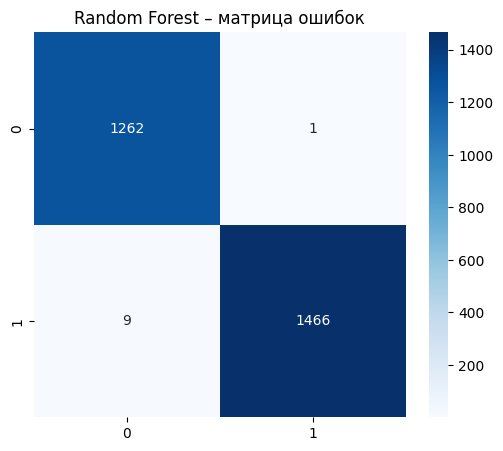

In [18]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest – матрица ошибок")
plt.savefig("rf_confusion.png")
plt.show()

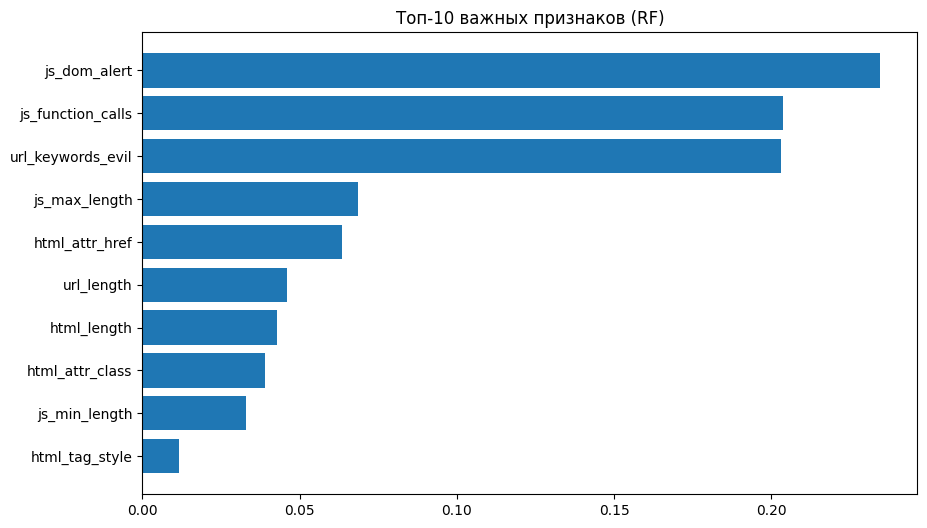

In [19]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:10]
plt.figure(figsize=(10,6))
plt.barh(range(10), importances[indices])
plt.yticks(range(10), [X.columns[i] for i in indices])
plt.gca().invert_yaxis()
plt.title("Топ-10 важных признаков (RF)")
plt.savefig("rf_features.png")
plt.show()

In [20]:
joblib.dump(rf, "random_forest_xss.pkl")
print("Модель сохранена как random_forest_xss.pkl")

Модель сохранена как random_forest_xss.pkl



ОЦЕНКА НА ТЕСТОВОМ ДАТАСЕТЕ (Random Forest)
Загружено 13226 тестовых примеров
Извлечение признаков: 0/13226
Извлечение признаков: 500/13226
Извлечение признаков: 1000/13226
Извлечение признаков: 1500/13226
Извлечение признаков: 2000/13226
Извлечение признаков: 2500/13226
Извлечение признаков: 3000/13226
Извлечение признаков: 3500/13226
Извлечение признаков: 4000/13226
Извлечение признаков: 4500/13226
Извлечение признаков: 5000/13226
Извлечение признаков: 5500/13226
Извлечение признаков: 6000/13226
Извлечение признаков: 6500/13226
Извлечение признаков: 7000/13226
Извлечение признаков: 7500/13226
Извлечение признаков: 8000/13226
Извлечение признаков: 8500/13226
Извлечение признаков: 9000/13226
Извлечение признаков: 9500/13226
Извлечение признаков: 10000/13226
Извлечение признаков: 10500/13226
Извлечение признаков: 11000/13226
Извлечение признаков: 11500/13226
Извлечение признаков: 12000/13226
Извлечение признаков: 12500/13226
Извлечение признаков: 13000/13226

📊 Classification Report:
 

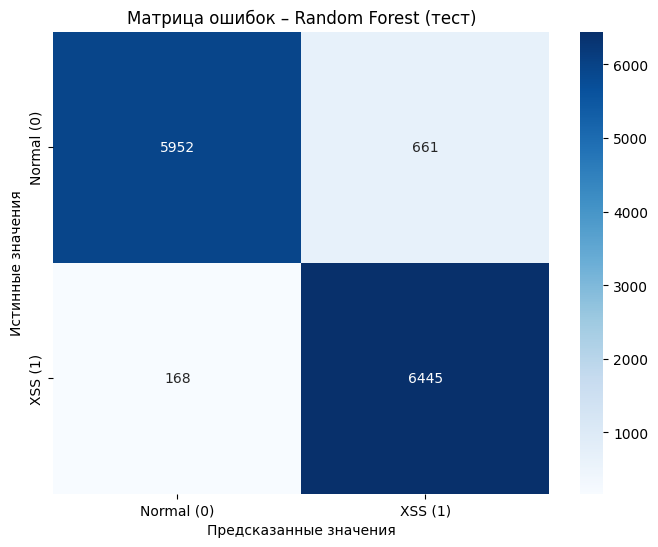


📈 Основные метрики:
Accuracy:  93.73%
Precision: 90.70%
Recall:    97.46%
F1-score:  93.96%
FP rate:   10.00%

🧪 Тест на отдельных примерах:

📝 <script>alert('XSS')</script>
   Предсказание: XSS | Вероятность: 99.98% | Ожидалось: XSS

📝 <div>Hello World</div>
   Предсказание: Normal | Вероятность: 1.67% | Ожидалось: Normal

📝 <img src=x onerror=alert(1)>
   Предсказание: XSS | Вероятность: 99.93% | Ожидалось: XSS

📝 <p>Normal paragraph</p>
   Предсказание: Normal | Вероятность: 4.60% | Ожидалось: Normal


In [23]:
# ========== БЛОК ОЦЕНКИ НА ТЕСТОВОМ ДАТАСЕТЕ ==========
print("\n" + "="*60)
print("ОЦЕНКА НА ТЕСТОВОМ ДАТАСЕТЕ (Random Forest)")
print("="*60)

test_df = pd.read_csv("../datasets_test/xss_dataset.csv")
print(f"Загружено {len(test_df)} тестовых примеров")

test_features = []
for i, text in enumerate(test_df['text']):
    if i % 500 == 0:
        print(f"Извлечение признаков: {i}/{len(test_df)}")
    test_features.append(extract_features(text, False))

X_test_full = pd.DataFrame(test_features)
y_test_full = test_df['label'].values

y_pred_full = rf.predict(X_test_full)
y_proba_full = rf.predict_proba(X_test_full)[:, 1]

print("\n📊 Classification Report:")
print(classification_report(y_test_full, y_pred_full))
print(f"AUC: {roc_auc_score(y_test_full, y_proba_full):.4f}")

cm_full = confusion_matrix(y_test_full, y_pred_full)
plt.figure(figsize=(8,6))
sns.heatmap(cm_full, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'XSS (1)'],
            yticklabels=['Normal (0)', 'XSS (1)'])
plt.title('Матрица ошибок – Random Forest (тест)')
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.savefig('rf_test_confusion.png')
plt.show()

TN, FP, FN, TP = cm_full.ravel()
precision = TP / (TP + FP) if (TP+FP) > 0 else 0
recall = TP / (TP + FN) if (TP+FN) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision+recall) > 0 else 0
accuracy = (TP+TN)/(TP+TN+FP+FN)

print("\n📈 Основные метрики:")
print(f"Accuracy:  {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")
print(f"F1-score:  {f1:.2%}")
print(f"FP rate:   {FP/(FP+TN):.2%}")

test_cases = [
    ("<script>alert('XSS')</script>", True),
    ("<div>Hello World</div>", False),
    ("<img src=x onerror=alert(1)>", True),
    ("<p>Normal paragraph</p>", False),
]
print("\n🧪 Тест на отдельных примерах:")
for code, expected in test_cases:
    feat = extract_features(code, False)
    feat_df = pd.DataFrame([feat])
    prob = rf.predict_proba(feat_df)[0][1]
    pred = prob >= 0.5
    print(f"\n📝 {code[:50]}")
    print(f"   Предсказание: {'XSS' if pred else 'Normal'} | Вероятность: {prob:.2%} | Ожидалось: {'XSS' if expected else 'Normal'}")